# Visual GR validation against SIM5
This optional notebook compares cached primary-image continuum calculations produced independently by microcaustics and SIM5. Set `MICROCAUSTICS_SIM5_DIR` to a case directory containing `comparison_data.npz`. The external code remains a validation dependency, not a runtime dependency.

## Pixel-level comparison
This cell reconstructs the manuscript validation figure from the independent raw microcaustics and SIM5 products. The upper row compares the frequency shift, the lower row compares the shared bolometric brightness proxy, and the right column shows signed percent residuals under the same masks and coordinate convention used in the paper.

In [1]:
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import microcaustics.plotting as mcp
plt.rcParams.update(mcp.publication_style())
def workspace_root():
    candidates = (Path(mcp.__file__).resolve().parents[4], Path.cwd(), *Path.cwd().parents)
    return next(
        (path for path in candidates if (path / 'microcaustics_package').is_dir() and (path / 'output').is_dir()),
        Path.cwd(),
    )

default_case = workspace_root() / 'output/final_paper_run_production_v4/sim5/Q2237_0305'
case_dir = Path(os.environ.get('MICROCAUSTICS_SIM5_DIR', default_case))
comparison_path = case_dir / 'comparison_data.npz'
print('SIM5 comparison:', 'configured' if comparison_path.is_file() else 'not configured')

SIM5 comparison: configured


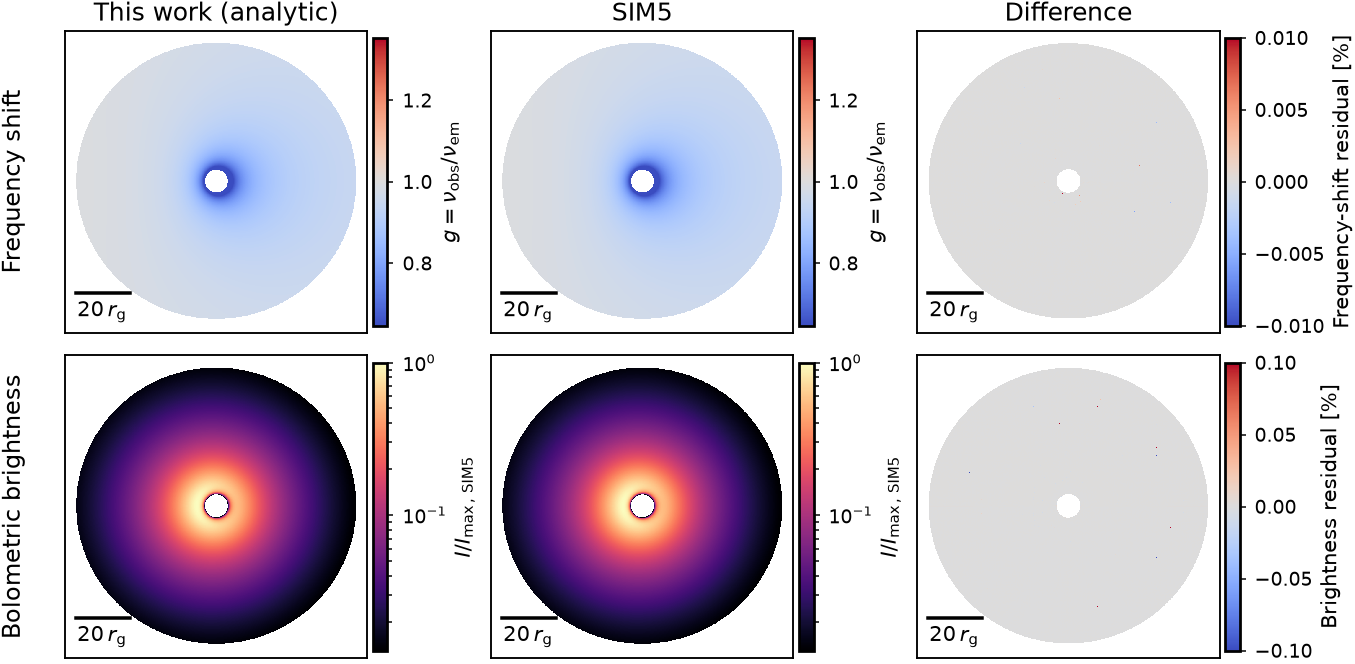

RMS symmetric fractional brightness residual: 1.624838442417231e-05


In [2]:
if comparison_path.exists():
    output_directory = case_dir / "notebook_visual_validation"
    figure_path = mcp.render_paper_sim5_validation(case_dir, output_directory)
    from IPython.display import Image, display
    display(Image(filename=str(figure_path)))
    with np.load(comparison_path, allow_pickle=False) as data:
        residual = np.asarray(data["intensity_symmetric_fractional"], dtype=float)
    print("RMS symmetric fractional brightness residual:", float(np.sqrt(np.nanmean(residual**2))))
else:
    print("Set MICROCAUSTICS_SIM5_DIR and rerun this cell.")


The comparison mask excludes pixels not shared by both primary-image solutions and should be reported with any residual statistic. Runtime comparisons should likewise state whether first-call compilation is included.